# Notebook 2 — Exploratory Data Analysis (EDA)
### Crash Risk Intelligence System
**Goal:** Understand patterns in the cleaned crash data through
three layers of analysis — Univariate, Bivariate, and Multivariate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load the cleaned dataset from Notebook 1
df = pd.read_csv('C:\crash_risk_intelligence\data\cleaned_crash_data.csv', low_memory=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 215,034
Columns: 34


## Part 1 — Univariate Analysis
Analyzing each column individually to understand its distribution,
shape, and key characteristics before looking at relationships.

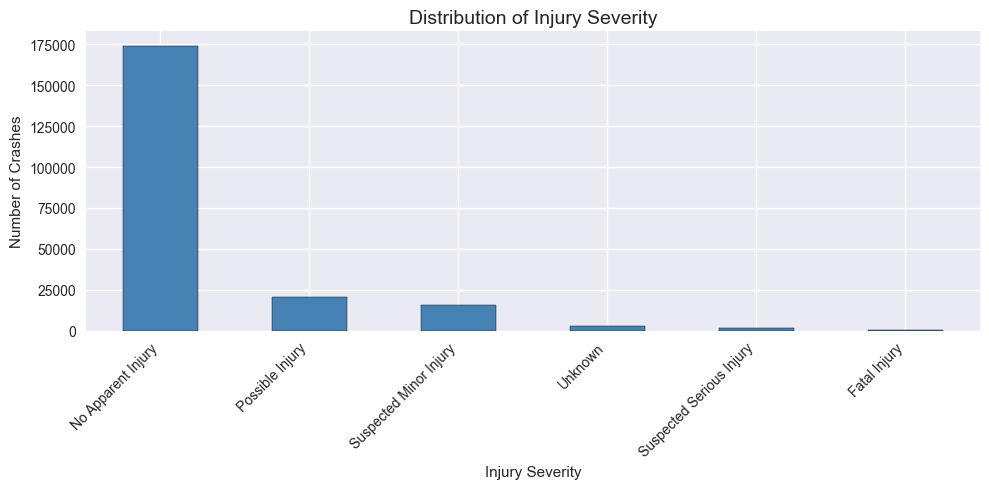


Value counts:
Injury Severity
No Apparent Injury          174212
Possible Injury              20349
Suspected Minor Injury       15474
Unknown                       3052
Suspected Serious Injury      1746
Fatal Injury                   201
Name: count, dtype: int64


In [3]:
# Injury Severity value counts
plt.figure(figsize=(10, 5))
df['Injury Severity'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Injury Severity', fontsize=14)
plt.xlabel('Injury Severity')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nValue counts:")
print(df['Injury Severity'].value_counts())

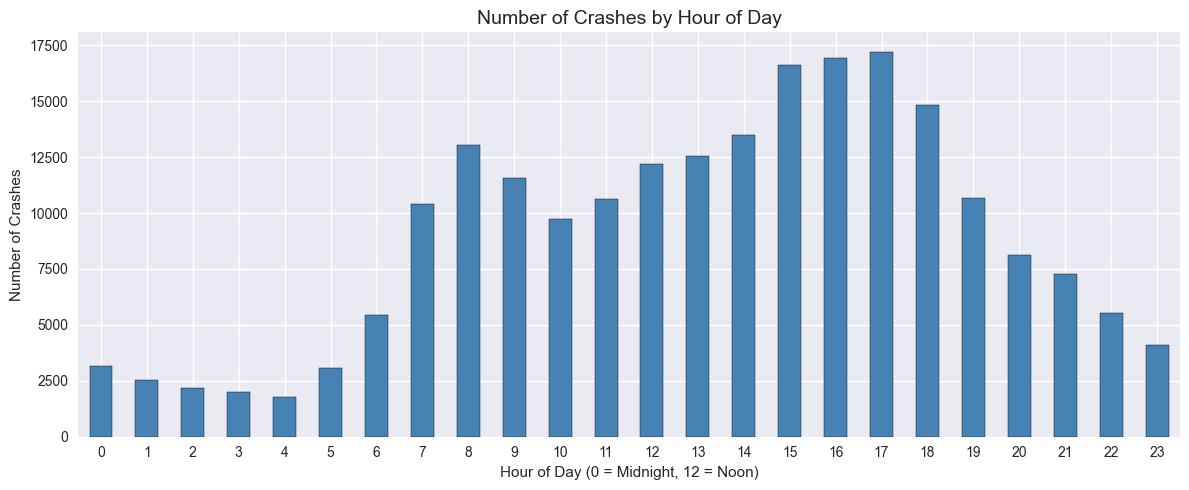


Peak crash hour: 17:00
Lowest crash hour: 4:00


In [4]:
# Convert Crash Date/Time to datetime first
df['Crash Date/Time'] = pd.to_datetime(df['Crash Date/Time'], errors='coerce')

# Extract hour
df['Crash Hour'] = df['Crash Date/Time'].dt.hour

# Plot
plt.figure(figsize=(12, 5))
df['Crash Hour'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Crashes by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nPeak crash hour: {df['Crash Hour'].value_counts().idxmax()}:00")
print(f"Lowest crash hour: {df['Crash Hour'].value_counts().idxmin()}:00")

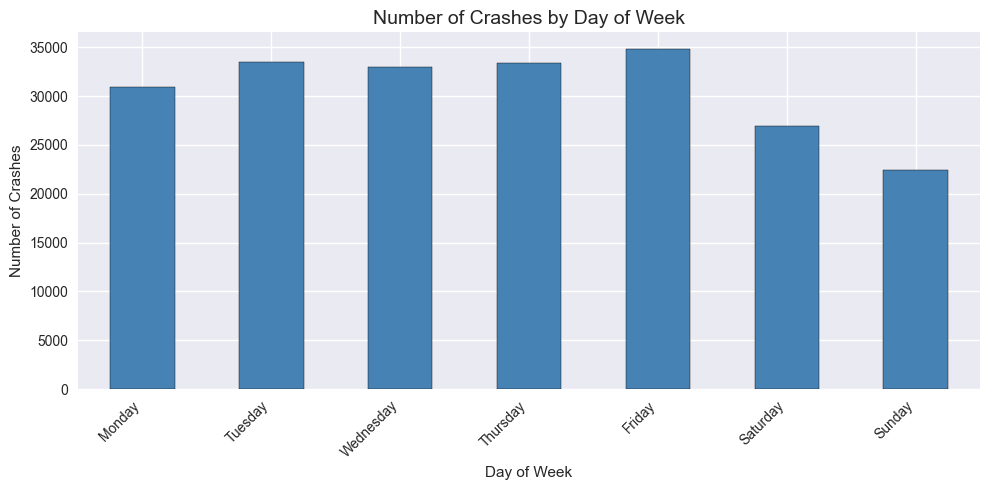


Crashes by day:
Crash Day
Monday       30977
Tuesday      33486
Wednesday    32981
Thursday     33376
Friday       34789
Saturday     26951
Sunday       22474
Name: count, dtype: int64


In [5]:
# Extract day of week
df['Crash Day'] = df['Crash Date/Time'].dt.day_name()

# Define correct order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plot
plt.figure(figsize=(10, 5))
df['Crash Day'].value_counts().reindex(day_order).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Crashes by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nCrashes by day:")
print(df['Crash Day'].value_counts().reindex(day_order))

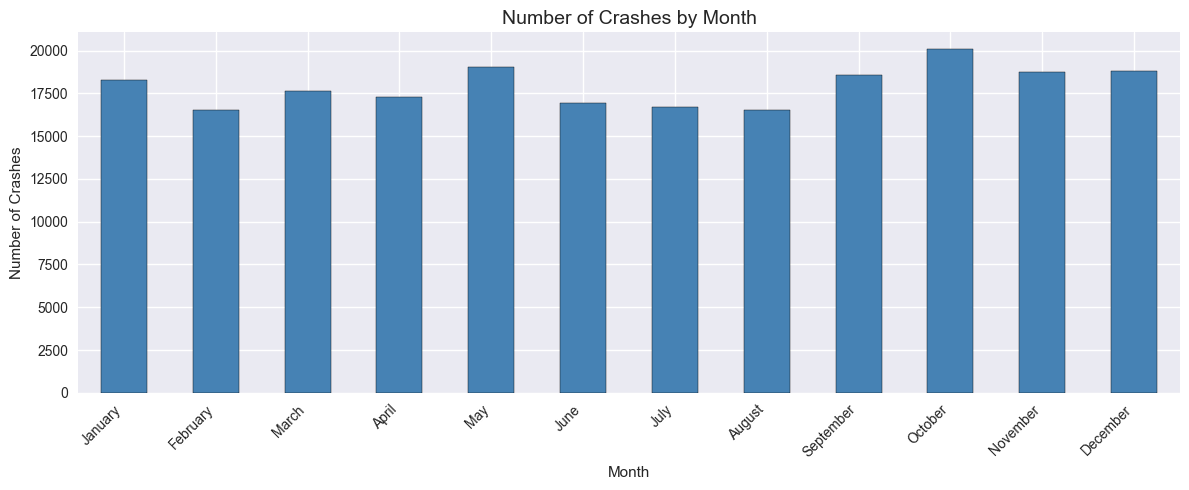


Crashes by month:
Crash Month
January      18271
February     16509
March        17631
April        17269
May          19026
June         16932
July         16678
August       16536
September    18560
October      20061
November     18750
December     18811
Name: count, dtype: int64


In [6]:
# Extract month
df['Crash Month'] = df['Crash Date/Time'].dt.month_name()

# Define correct order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Plot
plt.figure(figsize=(12, 5))
df['Crash Month'].value_counts().reindex(month_order).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Crashes by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nCrashes by month:")
print(df['Crash Month'].value_counts().reindex(month_order))

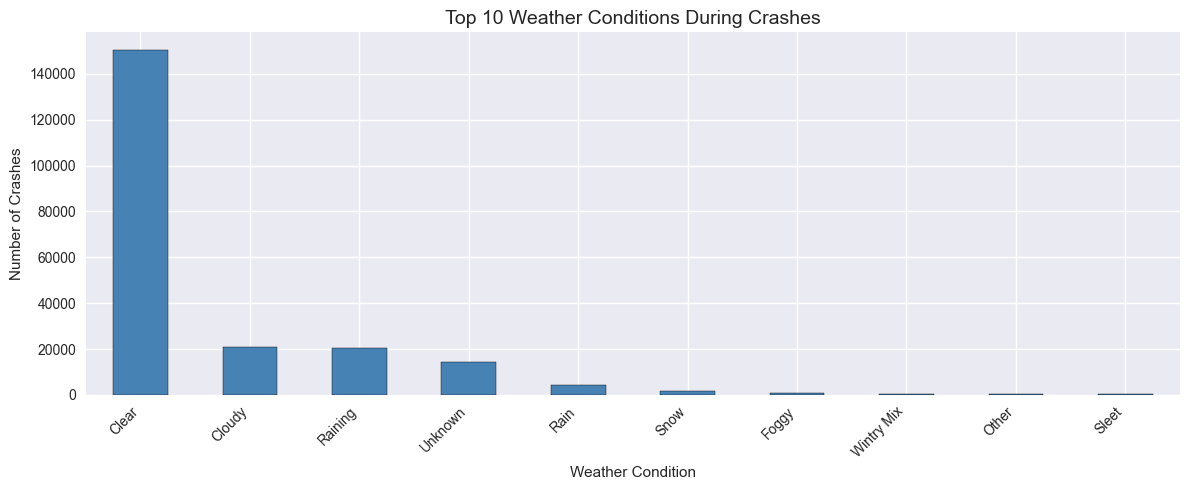


Weather value counts:
Weather
Clear         150628
Cloudy         21068
Raining        20609
Unknown        14348
Rain            4215
Snow            1898
Foggy            676
Wintry Mix       391
Other            370
Sleet            218
Name: count, dtype: int64


In [7]:
# Plot Weather conditions
plt.figure(figsize=(12, 5))
df['Weather'].value_counts().head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Weather Conditions During Crashes', fontsize=14)
plt.xlabel('Weather Condition')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nWeather value counts:")
print(df['Weather'].value_counts().head(10))

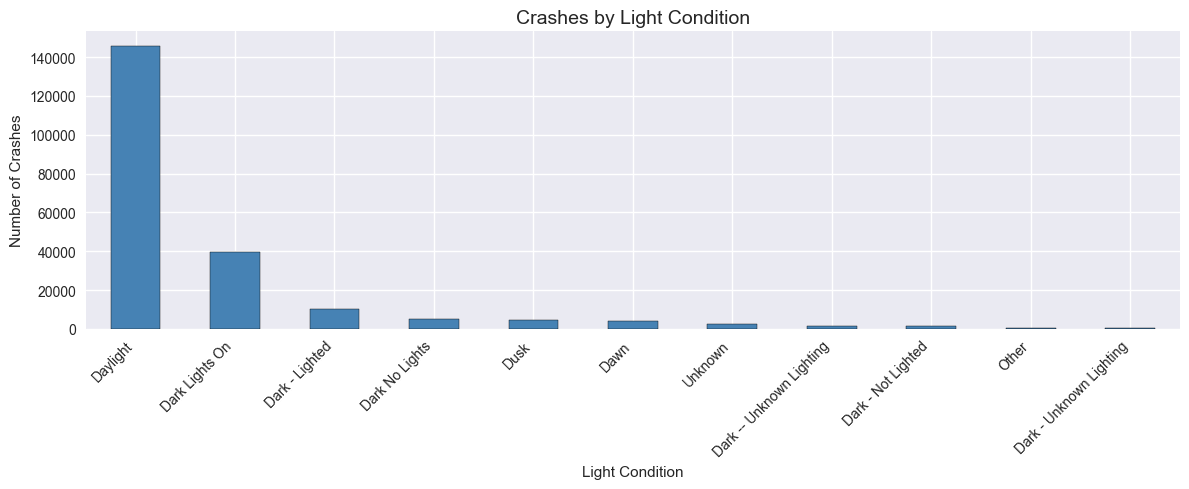


Light condition counts:
Light
Daylight                    145974
Dark Lights On               39551
Dark - Lighted               10000
Dark No Lights                4966
Dusk                          4534
Dawn                          3904
Unknown                       2321
Dark -- Unknown Lighting      1578
Dark - Not Lighted            1488
Other                          469
Dark - Unknown Lighting        249
Name: count, dtype: int64


In [8]:
# Plot Light conditions
plt.figure(figsize=(12, 5))
df['Light'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Crashes by Light Condition', fontsize=14)
plt.xlabel('Light Condition')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nLight condition counts:")
print(df['Light'].value_counts())

## Part 2 — Bivariate Analysis
Analyzing relationships between two variables to understand
how different factors influence crash severity.

<Figure size 1400x600 with 0 Axes>

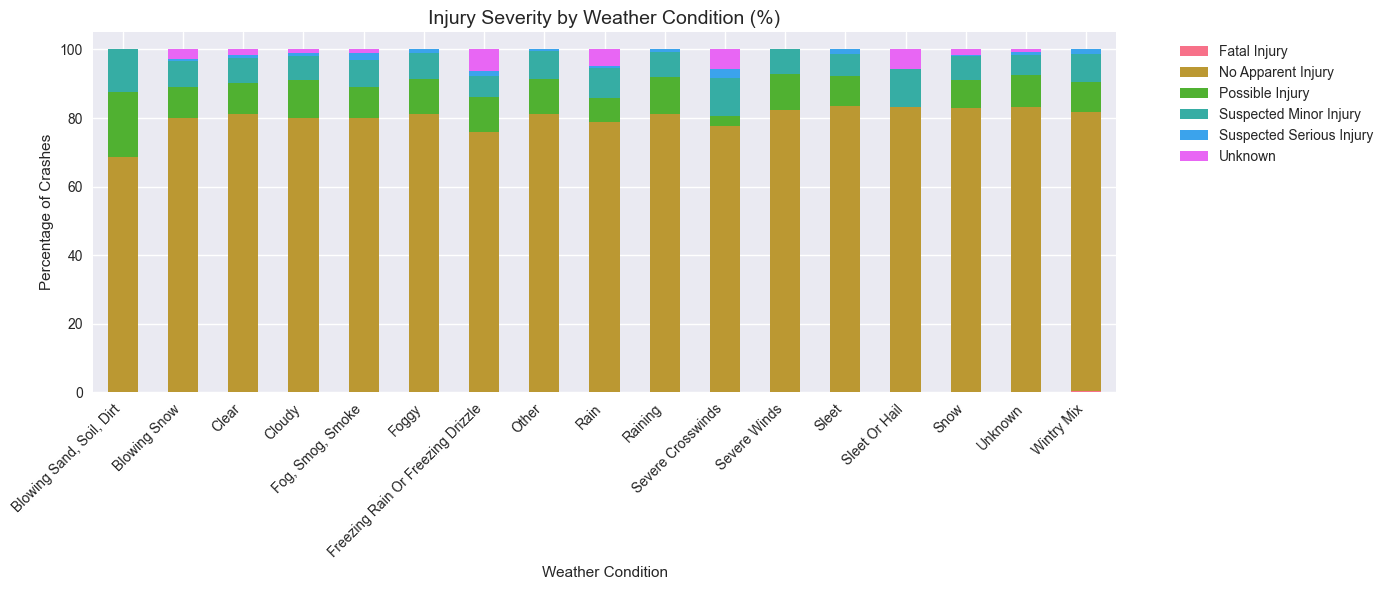

In [9]:
# Weather vs Injury Severity
plt.figure(figsize=(14, 6))
weather_severity = pd.crosstab(df['Weather'], df['Injury Severity'], normalize='index') * 100
weather_severity.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Injury Severity by Weather Condition (%)', fontsize=14)
plt.xlabel('Weather Condition')
plt.ylabel('Percentage of Crashes')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

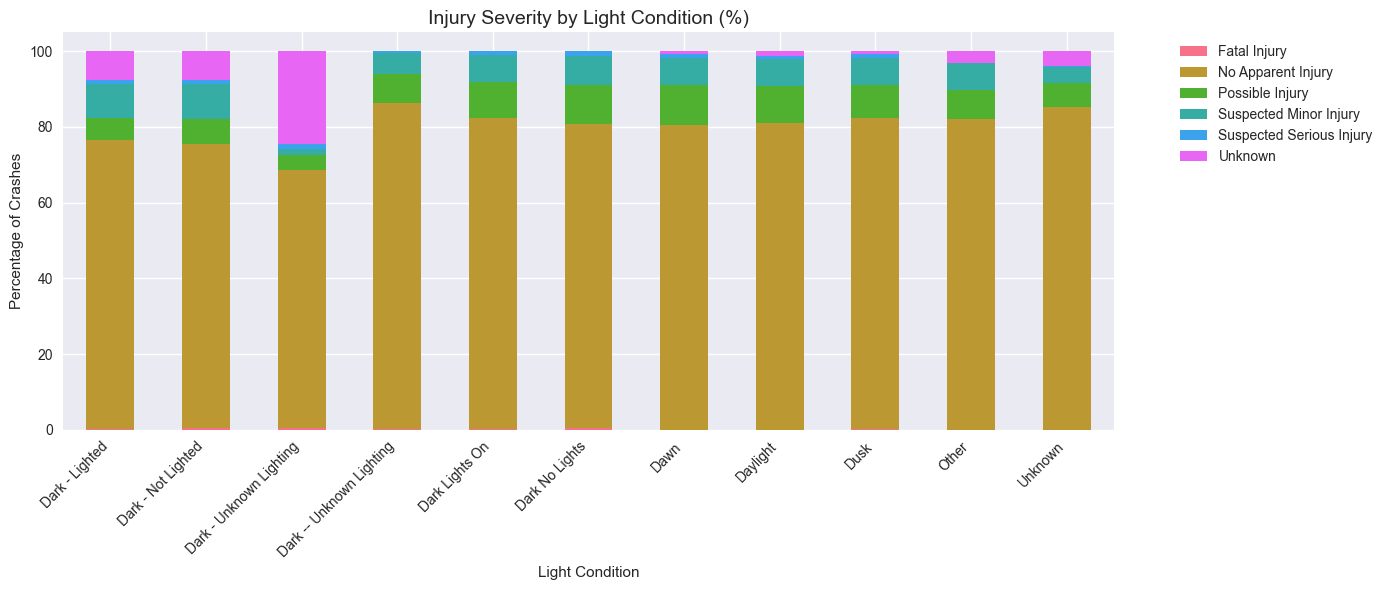

In [10]:
# Light vs Injury Severity
plt.figure(figsize=(14, 6))
light_severity = pd.crosstab(df['Light'], df['Injury Severity'], normalize='index') * 100
light_severity.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Injury Severity by Light Condition (%)', fontsize=14)
plt.xlabel('Light Condition')
plt.ylabel('Percentage of Crashes')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

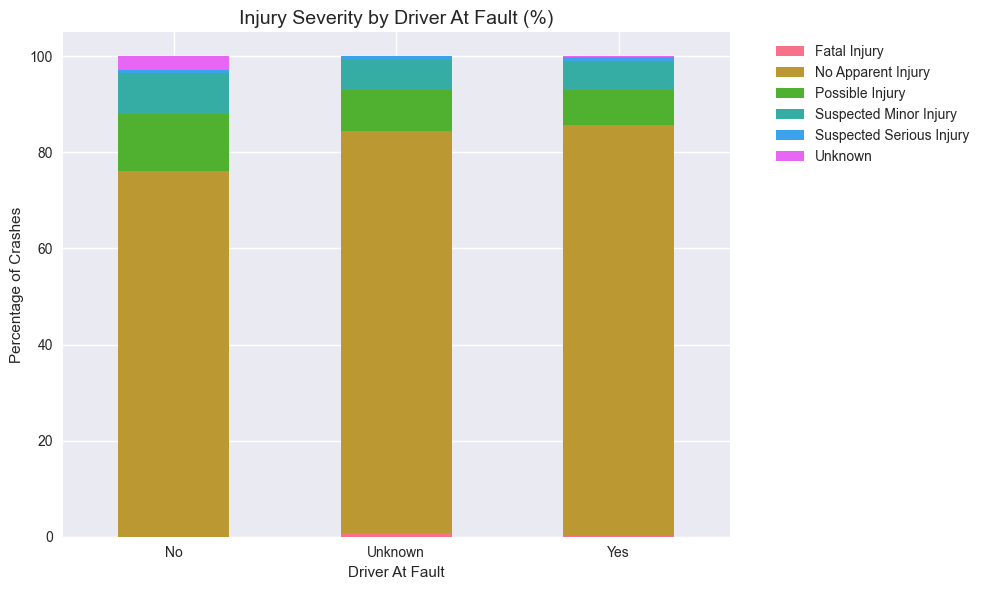


Driver At Fault value counts:
Driver At Fault
Yes        107081
No         103271
Unknown      4682
Name: count, dtype: int64


In [11]:
# Driver At Fault vs Injury Severity
plt.figure(figsize=(10, 6))
fault_severity = pd.crosstab(df['Driver At Fault'], df['Injury Severity'], normalize='index') * 100
fault_severity.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Injury Severity by Driver At Fault (%)', fontsize=14)
plt.xlabel('Driver At Fault')
plt.ylabel('Percentage of Crashes')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nDriver At Fault value counts:")
print(df['Driver At Fault'].value_counts())

## Part 3 — Multivariate Analysis
Looking at relationships between three or more variables
simultaneously to find deeper patterns in the data.

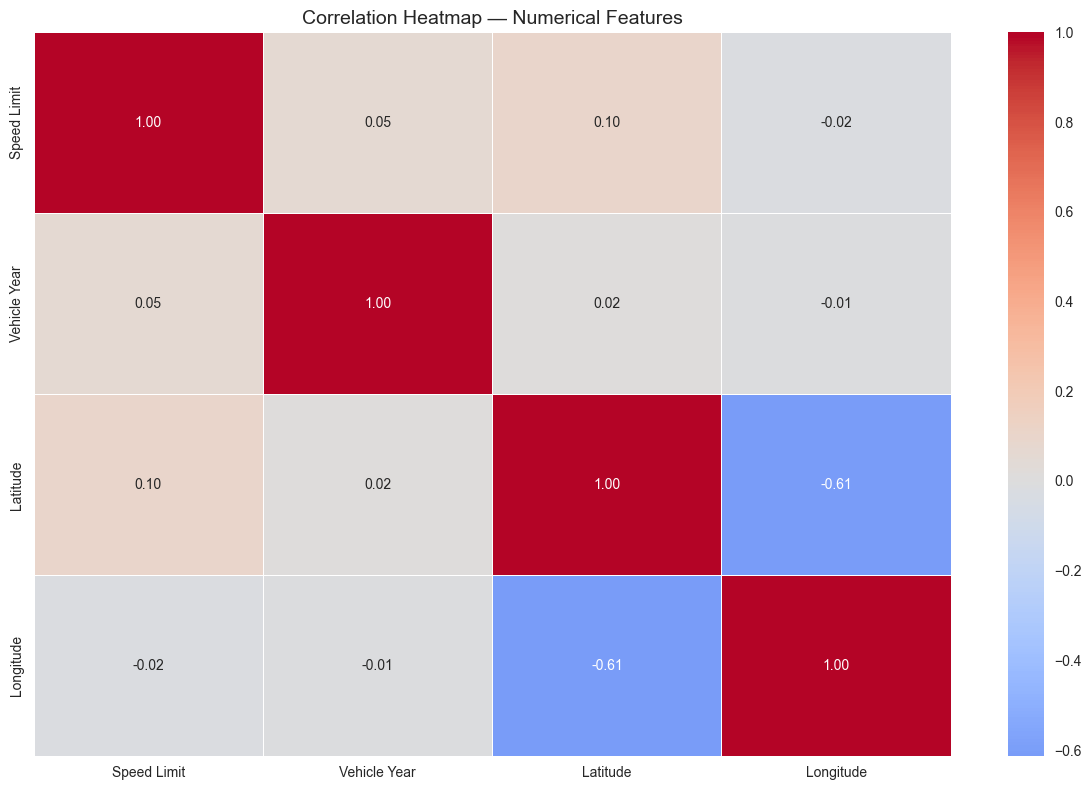

In [12]:
# Select numerical columns only
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

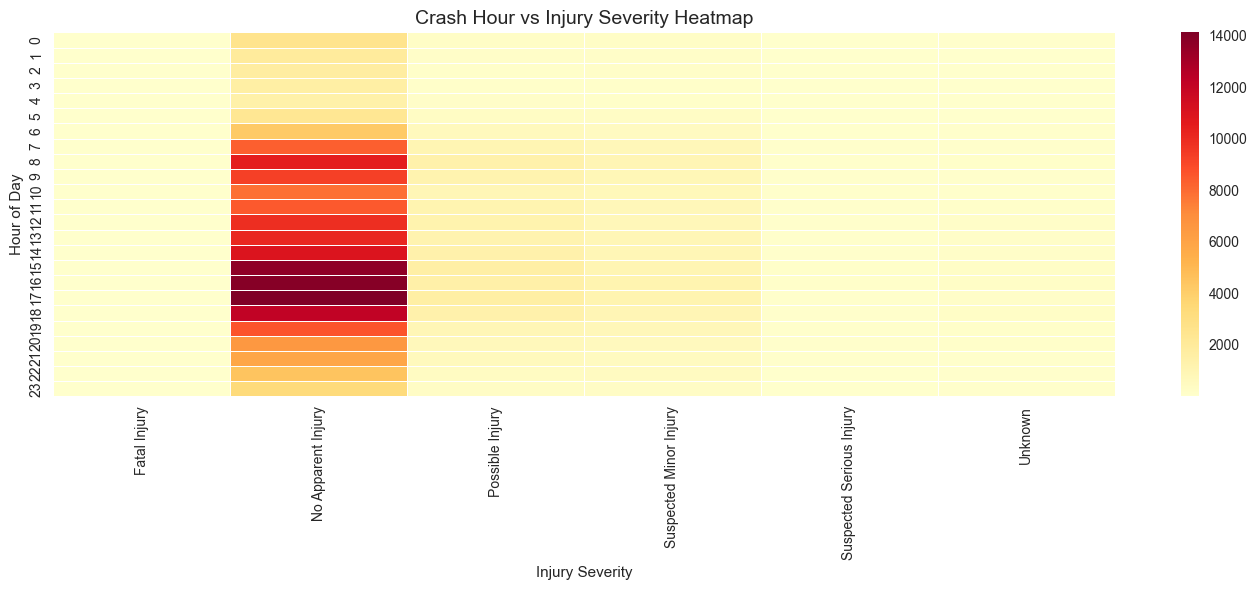

In [13]:
# Crash Hour vs Injury Severity heatmap
plt.figure(figsize=(14, 6))
hour_severity = pd.crosstab(df['Crash Hour'], df['Injury Severity'])
sns.heatmap(hour_severity, 
            cmap='YlOrRd',
            linewidths=0.5,
            annot=False)
plt.title('Crash Hour vs Injury Severity Heatmap', fontsize=14)
plt.xlabel('Injury Severity')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

## EDA Summary — Key Findings

### Univariate
- Most crashes result in No Apparent Injury
- Peak crash hours are 8am and 3-5pm (rush hours)
- Weekdays have consistently more crashes than weekends
- Slight peaks in January, May and October
- Clear weather has most crashes due to exposure bias

### Bivariate
- Blowing sand has highest serious injury percentage
- Dark and dawn conditions linked to higher possible injuries
- Drivers not at fault tend to have higher injury rates

### Multivariate
- No strong numerical correlations — relationships are categorical
- Evening and nighttime hours show slight increase in possible injuries
- Hour alone is weak predictor — ML needed to combine multiple factors

In [ ]:
# Save dataframe with new columns added during EDA for next notebook
df.to_csv('C:\crash_risk_intelligence\data\eda_crash_data.csv', index=False)
print(f"EDA data saved with new columns: {df.shape}")
print(f"New columns added: {['Crash Hour', 'Crash Day', 'Crash Month']}")